In [310]:
#### Requirment
# Pandas
# Matplotlib
# Seaborn
# Scikit-learn
# BM_NLP_Classification_WP
# Pickle
# streamlit

# 1. Import the libraries

In [359]:
# Basic libraries
import re
import pandas as pd
import numpy as np

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupKFold

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

import BM_NLP_Classification_WP

import importlib
importlib.reload(BM_NLP_Classification_WP)

import pickle


# 2. Load the dataset

In [312]:
# First read attempt
DF = pd.read_csv("twitter_training.csv")

In [313]:
# Preview the first rows to confirm the header problem
DF.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,"I am coming to the borders and I will kill you all,"
1,2401,Borderlands,Positive,"im getting on borderlands and i will kill you all,"
2,2401,Borderlands,Positive,"im coming on borderlands and i will murder you all,"
3,2401,Borderlands,Positive,"im getting on borderlands 2 and i will murder you me all,"
4,2401,Borderlands,Positive,"im getting into borderlands and i can murder you all,"


In [314]:
# Read again with header=None and give the four columns proper names
DF = pd.read_csv("twitter_training.csv",
                 header=None,
                 names=["ID", "Entity", "Sentiment", "Text"])

In [315]:
DF.head()

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
1,2401,Borderlands,Positive,"I am coming to the borders and I will kill you all,"
2,2401,Borderlands,Positive,"im getting on borderlands and i will kill you all,"
3,2401,Borderlands,Positive,"im coming on borderlands and i will murder you all,"
4,2401,Borderlands,Positive,"im getting on borderlands 2 and i will murder you me all,"


# This is a multiclass NLP text-classification problem.

In [316]:
# Number of rows and columns in the dataset
DF.shape

(74682, 4)

In [317]:
# Column names, non-null counts and data types
DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


In [318]:
# Count the missing values in each column
DF.isna().sum()

ID             0
Entity         0
Sentiment      0
Text         686
dtype: int64

In [319]:
# Count how many rows are exact duplicates
DF.duplicated().sum()

np.int64(2700)

In [320]:
# Work on a copy so the original DataFrame stays untouched
df = DF.copy()

# 3. Explore the data (EDA)

In [321]:
# To find out many tweets of each sentiment do we have
print(df["Sentiment"].value_counts())
print()
print("In percentage:")
print(df["Sentiment"].value_counts(normalize=True).round(3) * 100)

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In percentage:
Sentiment
Negative      30.2
Positive      27.9
Neutral       24.5
Irrelevant    17.4
Name: proportion, dtype: float64


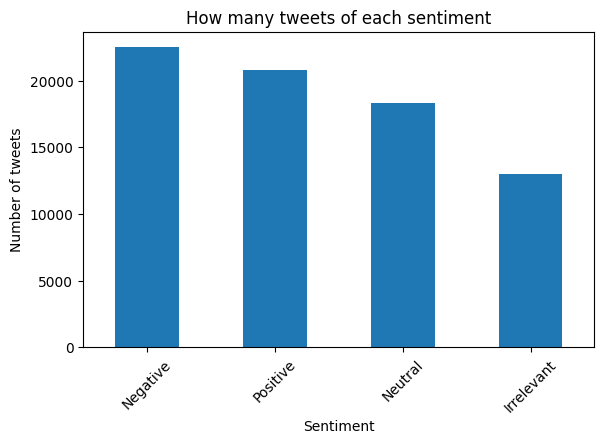

In [322]:
# Bar plot of the sentiment
df["Sentiment"].value_counts().plot(kind="bar")

plt.title("How many tweets of each sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of tweets")
plt.xticks(rotation=45)

plt.tight_layout(pad=2.0)
plt.show()

Number of Entities: 32


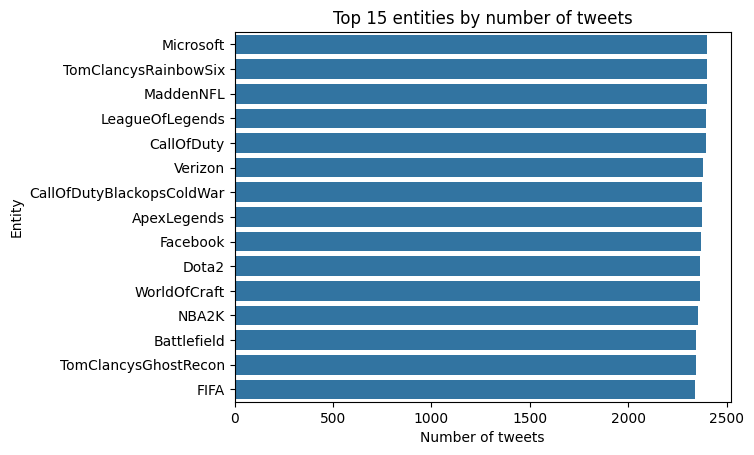

In [323]:
# To find out how many different entities (topics) are there
print("Number of Entities:", df["Entity"].nunique())

# The 15 most common ones
top_entities = df["Entity"].value_counts().head(15)
sns.barplot(x=top_entities.values, y=top_entities.index)
plt.title("Top 15 entities by number of tweets")
plt.xlabel("Number of tweets")
plt.ylabel("Entity")
plt.show()

In [324]:
#New: Check how many rows share the same ID.
rows_per_id = len(df) / df["ID"].nunique()

print("Number of rows      :", len(df))
print("Number of unique IDs:", df["ID"].nunique())
print("Rows per ID         :", round(rows_per_id, 2))

Number of rows      : 74682
Number of unique IDs: 12447
Rows per ID         : 6.0


In [325]:
# NEW: Look at one ID to see what those rows actually look like
df[df["ID"] == 2401]

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
1,2401,Borderlands,Positive,"I am coming to the borders and I will kill you all,"
2,2401,Borderlands,Positive,"im getting on borderlands and i will kill you all,"
3,2401,Borderlands,Positive,"im coming on borderlands and i will murder you all,"
4,2401,Borderlands,Positive,"im getting on borderlands 2 and i will murder you me all,"
5,2401,Borderlands,Positive,"im getting into borderlands and i can murder you all,"


In [326]:
# Look at a few example tweets for each sentiment
for label in ["Positive", "Negative", "Neutral", "Irrelevant"]:
    print("=" * 60)
    print(label)
    print("=" * 60)
    examples = df[df["Sentiment"] == label]["Text"].dropna().head(3)
    for tweet in examples:
        print(tweet)

Positive
im getting on borderlands and i will murder you all ,
I am coming to the borders and I will kill you all,
im getting on borderlands and i will kill you all,
Negative
the biggest dissappoinment in my life came out a year ago fuck borderlands 3
The biggest disappointment of my life came a year ago.
The biggest disappointment of my life came a year ago.
Neutral
Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dlvr.it/RMTrgF  
Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dlvr.it / RMTrgF
Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dfr.it / RMTrgF
Irrelevant
Appreciate the (sonic) concepts / praxis Valenzuela and Landa-Posas thread together in this talk: multimodal listening, soundwalks, borderlands frameworks, participatory action research, and testimonios. . . So many thoughtful and resonant intersections here.. .  
Appreciate the (sound) concepts / practices that Valenzuela and Landa-

# 4. Clean the data

In [327]:
# Remove duplicated rows
df = df.drop_duplicates()

# Remove rows where the tweet text is missing
df = df.dropna(subset=["Text"])

# Reset the row numbers after deleting rows
df = df.reset_index(drop=True)

print("Rows and columns after cleaning:", df.shape)

Rows and columns after cleaning: (71656, 4)


# 4.1 Fix rows that have the same text but different labels

In [328]:
# Make a "comparison version" of the text: lowercase, single spaces, no space at the ends.
df["Text_Check"] = (
    df["Text"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [329]:
# Count how many different labels each text has
label_counts = df.groupby("Text_Check")["Sentiment"].nunique()

# The texts that have more than one label are the problem ones
conflicting_texts = label_counts[label_counts > 1].index

print("Texts with more than one label:", len(conflicting_texts))
print("Rows involved in the conflict :", df["Text_Check"].isin(conflicting_texts).sum())

Texts with more than one label: 127
Rows involved in the conflict : 2111


In [330]:
# Show a few of the conflicting rows so we can see the problem with our own eyes
conflicts = df[df["Text_Check"].isin(conflicting_texts)].sort_values("Text_Check")

conflicts[["ID", "Entity", "Sentiment", "Text"]].head(20)

,ID,Entity,Sentiment,Text
2212,1602,CallOfDutyBlackopsColdWar,Irrelevant,
2879,1719,CallOfDutyBlackopsColdWar,Positive,
3113,1763,CallOfDutyBlackopsColdWar,Neutral,
3773,1880,CallOfDutyBlackopsColdWar,Negative,
4047,1929,CallOfDutyBlackopsColdWar,Negative,
4211,1959,CallOfDutyBlackopsColdWar,Neutral,
4536,16,Amazon,Neutral,
4646,37,Amazon,Neutral,
4673,42,Amazon,Neutral,
5184,134,Amazon,Neutral,


In [331]:
# NEW: Give every identical text one single label
majority_label = (
    df.groupby("Text_Check")["Sentiment"]
      .agg(lambda labels: labels.mode()[0])
)

df["Sentiment"] = df["Text_Check"].map(majority_label)

print("Texts with more than one label now:",
      (df.groupby("Text_Check")["Sentiment"].nunique() > 1).sum())

Texts with more than one label now: 0


# 4.2 Clean the text itself

In [332]:
# NEW: A much shorter stopword list.
stopword_text = """
a an the and or of at by for with about into to from in on off over under then there
is am are was were be been being have has had having do does did doing
this that these those
"""

stopwords = set(stopword_text.split())
print("Number of stopwords:", len(stopwords))

Number of stopwords: 41


In [333]:
# Make a function to clean the Text 
def clean_text(text):
    """Take one tweet and return a cleaned version of it."""

    # 1. Make everything lowercase
    text = text.lower()

    # 2. Remove web links
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 3. Remove @mentions (like @netflix)
    text = re.sub(r"@\w+", " ", text)

    # 4. Keep only letters and spaces (removes numbers, emojis, punctuation)
    text = re.sub(r"[^a-z\s]", " ", text)

    # 5. Split into words, drop stopwords and very short words
    words = text.split()
    words = [w for w in words if w not in stopwords and len(w) > 2]

    # 6. Join the words back into one sentence
    return " ".join(words)

In [334]:
# Quick test on one sentence
sample = "I LOVE @Borderlands 3!!! Best game ever, check http://bl3.com :)"
print("Before:", sample)
print("After :", clean_text(sample))

Before: I LOVE @Borderlands 3!!! Best game ever, check http://bl3.com :)
After : love best game ever check


In [335]:
# NEW: Check the sentences that used to break the model.
# Before the fix these became a single word. Now the sentence survives.
for sentence in ["I will murder you",
                 "I will kill you all",
                 "I hate this game",
                 "This game is not good",
                 "I love this game"]:
    print(f"{sentence:25} -> {clean_text(sentence)}")

I will murder you         -> will murder you
I will kill you all       -> will kill you all
I hate this game          -> hate game
This game is not good     -> game not good
I love this game          -> love game


In [336]:
# Apply the cleaning function to every tweet
df["Clean_Text"] = df["Text"].apply(clean_text)

# Show the original and the cleaned version side by side
df[["Text", "Clean_Text", "Sentiment"]].head(10)

,Text,Clean_Text,Sentiment
0,"im getting on borderlands and i will murder you all ,",getting borderlands will murder you all,Positive
1,"I am coming to the borders and I will kill you all,",coming borders will kill you all,Positive
2,"im getting on borderlands and i will kill you all,",getting borderlands will kill you all,Positive
3,"im coming on borderlands and i will murder you all,",coming borderlands will murder you all,Positive
4,"im getting on borderlands 2 and i will murder you me all,",getting borderlands will murder you all,Positive
5,"im getting into borderlands and i can murder you all,",getting borderlands can murder you all,Positive
6,So I spent a few hours making something for fun. . . If you don't know I am a HUGE @Borderlands fan and Maya is one of my favorite characters. So I decided to make myself a wallpaper for my PC. . Here is the original image versus the creation I made :) Enjoy! pic.twitter.com/mLsI5wf9Jg,spent few hours making something fun you don know huge fan maya one favorite characters decided make myself wallpaper here original image versus creation made enjoy pic twitter com mlsi,Positive
7,"So I spent a couple of hours doing something for fun... If you don't know that I'm a huge @ Borderlands fan and Maya is one of my favorite characters, I decided to make a wallpaper for my PC.. Here's the original picture compared to the creation I made:) Have fun! pic.twitter.com / mLsI5wf9Jg",spent couple hours something fun you don know huge borderlands fan maya one favorite characters decided make wallpaper here original picture compared creation made fun pic twitter com mlsi,Positive
8,So I spent a few hours doing something for fun... If you don't know I'm a HUGE @ Borderlands fan and Maya is one of my favorite characters.,spent few hours something fun you don know huge borderlands fan maya one favorite characters,Positive
9,So I spent a few hours making something for fun. . . If you don't know I am a HUGE RhandlerR fan and Maya is one of my favorite characters. So I decided to make myself a wallpaper for my PC. . Here is the original image versus the creation I made :) Enjoy! pic.twitter.com/mLsI5wf9Jg,spent few hours making something fun you don know huge rhandlerr fan maya one favorite characters decided make myself wallpaper here original image versus creation made enjoy pic twitter com mlsi,Positive


In [337]:
# Find out empty tweets (for example a tweet with only a link),
empty_rows = (df["Clean_Text"].str.strip() == "").sum()
print("Empty tweets after cleaning:", empty_rows)

Empty tweets after cleaning: 1424


In [338]:
# Removing these rows because there is nothing left to learn
df = df[df["Clean_Text"].str.strip() != ""].reset_index(drop=True)
print("Final number of rows:", df.shape[0])

Final number of rows: 70232


In [339]:
# Find out how long are the tweets?
def count_words(text):
    return len(text.split())

df["word_count"] = df["Clean_Text"].apply(count_words)

In [340]:
# Basic statistics of the tweet length (mean, min, max, quartiles)
df["word_count"].describe()

count    70232.000000
mean        12.448457
std          8.680301
min          1.000000
25%          6.000000
50%         10.000000
75%         17.000000
max        130.000000
Name: word_count, dtype: float64

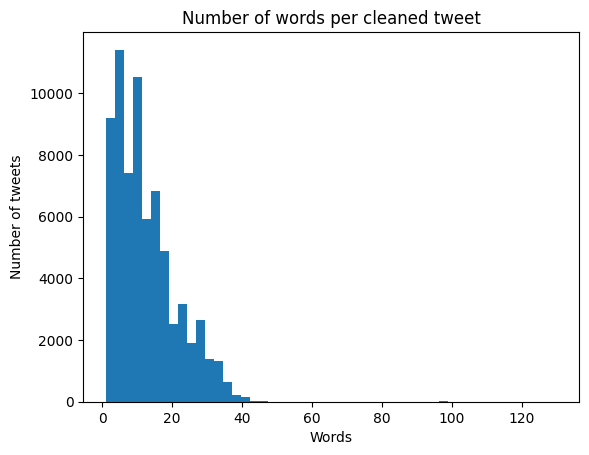

In [341]:
# Draw a histplot of word length of the tweets
plt.hist(df["word_count"], bins=50)
plt.title("Number of words per cleaned tweet")
plt.xlabel("Words")
plt.ylabel("Number of tweets")
plt.show()

In [342]:
# The most frequent words in the whole dataset
all_words = " ".join(df["Clean_Text"]).split()
word_freq = pd.Series(all_words).value_counts().head(20)

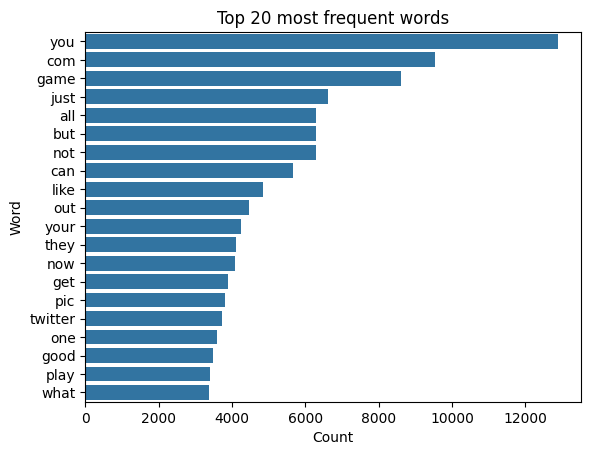

In [343]:
# # Draw a barplot of nubmer of most frequent words in the whole dataset.
sns.barplot(x=word_freq.values, y=word_freq.index)
plt.title("Top 20 most frequent words")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

# 5. Split the data into training and testing sets

In [344]:
# NEW: Split by ID instead of by row.

# 1. Take the list of all unique IDs
unique_ids = df["ID"].unique()

# 2. Shuffle them (random_state keeps the result the same on every run)
rng = np.random.RandomState(42)
rng.shuffle(unique_ids)

# 3. Put 20% of the IDs into the test set
n_test_ids = int(len(unique_ids) * 0.2)
test_ids = set(unique_ids[:n_test_ids])

# 4. A row goes to test if its ID is a test ID
is_test = df["ID"].isin(test_ids)

# 5. NEW: Shuffle the training rows.
train_rows = df.index[~is_test].to_numpy().copy()
rng.shuffle(train_rows)

test_rows = df.index[is_test].to_numpy().copy()

X_train = df.loc[train_rows, "Clean_Text"]
X_test  = df.loc[test_rows,  "Clean_Text"]

Y_train = df.loc[train_rows, "Sentiment"]
Y_test  = df.loc[test_rows,  "Sentiment"]

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 56200
Testing rows : 14032


In [345]:
# NEW: Safety check - no ID is allowed to appear in both sets.
train_ids = set(df.loc[~is_test, "ID"])
print("IDs in both train and test:", len(train_ids & test_ids))

IDs in both train and test: 0


In [346]:
# NEW: Check that both sets still have a similar mix of the four sentiments.
print("Train:")
print(Y_train.value_counts(normalize=True).round(3))
print()
print("Test:")
print(Y_test.value_counts(normalize=True).round(3))

Train:
Sentiment
Negative      0.301
Positive      0.272
Neutral       0.251
Irrelevant    0.176
Name: proportion, dtype: float64

Test:
Sentiment
Negative      0.304
Positive      0.288
Neutral       0.242
Irrelevant    0.166
Name: proportion, dtype: float64


# 6. Text to number

In [347]:
# TF-IDF turns each tweet into a numeric vector
# max_features: keep only the 20000 most useful terms
# ngram_range=(1, 2): use single words and word pairs
# min_df=3: ignore terms that appear in fewer than 3 tweets
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
)

# Convert the vocabulary of train data
X_train_t = tfidf.fit_transform(X_train)

# Convert the vocabulary of test data
X_test_t = tfidf.transform(X_test)

In [348]:
# print the shape of train and test data
print("Training matrix shape:", X_train_t.shape)
print("Testing matrix shape :", X_test_t.shape)

Training matrix shape: (56200, 20000)
Testing matrix shape : (14032, 20000)


# 7. Train the models

In [ ]:
# NEW: Add GroupKFold
# The ID of each training row, in the same order as X_train / Y_train
train_groups = df.loc[train_rows, "ID"]

# A plain list of (train, validation) folds. The helper accepts this in place of cv=5.
group_folds = list(
    GroupKFold(n_splits=5).split(X_train_t, Y_train, groups=train_groups)
)

print("Number of folds:", len(group_folds))

Number of folds: 5


In [349]:
# Train and compare several classifiers with cross-validation,
# then tune the best one and evaluate it on the test set
result = BM_NLP_Classification_WP.universal_nlp_classifier(
    X_train_t,
    Y_train,
    X_test=X_test_t,
    y_test=Y_test
)


Model Comparison:
                     Model  CV Accuracy  CV Precision  CV Recall   CV F1
0               Linear SVC       0.8892        0.8896     0.8892  0.8891
1      Logistic Regression       0.8168        0.8188     0.8168  0.8155
2           SGD Classifier       0.7623        0.7744     0.7623  0.7577
3  Multinomial Naive Bayes       0.7570        0.7752     0.7570  0.7516

Best Model Based on CV F1: Linear SVC

Best Parameters:
{'C': 1, 'class_weight': 'balanced'}

Best CV Score After Tuning:
0.8893

Test Performance:
Accuracy : 0.5116
Precision: 0.5092
Recall   : 0.5116
F1 Score : 0.5103

Test Confusion Matrix:
[[ 738  505  442  651]
 [ 461 2622  557  627]
 [ 532  614 1560  683]
 [ 487  571  723 2259]]

Test Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.33      0.32      0.32      2336
    Negative       0.61      0.61      0.61      4267
     Neutral       0.48      0.46      0.47      3389
    Positive       0.54      0.5

In [350]:
# Name of the model that scored best
result["best_model_name"]

'Linear SVC'

In [351]:
# Hyper-parameters found by the tuning step
result["best_params"]

{'C': 1, 'class_weight': 'balanced'}

In [352]:
# Cross-validation scores of every model that was tried
result["results"]

,Model,CV Accuracy,CV Precision,CV Recall,CV F1
0,Linear SVC,0.8892,0.8896,0.8892,0.8891
1,Logistic Regression,0.8168,0.8188,0.8168,0.8155
2,SGD Classifier,0.7623,0.7744,0.7623,0.7577
3,Multinomial Naive Bayes,0.7570,0.7752,0.7570,0.7516


In [353]:
# Keep the fitted best model in a variable
best_model = result["model"]

In [354]:
# Predict on the training data to check how well the model fits it
train_pred = result["model"].predict(X_train_t)

print(
    classification_report(
        Y_train,
        train_pred
    )
)

              precision    recall  f1-score   support

  Irrelevant       0.96      0.95      0.95      9885
    Negative       0.97      0.97      0.97     16903
     Neutral       0.97      0.96      0.96     14100
    Positive       0.94      0.96      0.95     15312

    accuracy                           0.96     56200
   macro avg       0.96      0.96      0.96     56200
weighted avg       0.96      0.96      0.96     56200



In [355]:
# Compare train and test F1 to check for overfitting
print(
    "Train F1:",
    f1_score(
        Y_train,
        train_pred,
        average="weighted"
    )
)

print(
    "Test F1:",
    f1_score(
        Y_test,
        result["test_pred"],
        average="weighted"
    )
)

Train F1: 0.959044011950664
Test F1: 0.5102738961946942


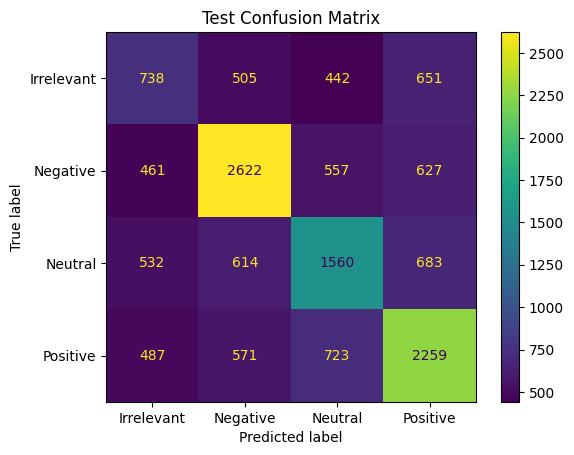

In [356]:
# Plot the confusion matrix of the test predictions
ConfusionMatrixDisplay.from_predictions(
    Y_test,
    result["test_pred"]
)

plt.title("Test Confusion Matrix")
plt.show()

In [357]:
# save the model
with open("sentiment_nlp_model.pkl", "wb") as file:

    pickle.dump(result["model"], file)

In [358]:
# Save the fitted vectorizer too, it is needed to transform new tweets
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)